#### Step 1: load the data

In [1]:
# Import all the tools we need

# Regular EDA (exploratory data analysis) and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import seaborn as sns

# we want our plots to appear inside the notebook
%matplotlib inline 


# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report,ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay , roc_curve

In [2]:
df=pd.read_csv(r"C:\Users\KOMAL\Desktop\heart-attack-predcton-system\heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


#### Step 2: Analyzing the dataset
#### 🧠 What's the Dataset About?
##### This dataset is all about predicting whether a patient is likely to have heart disease using measurable attributes from clinical tests and patient history. It’s a classification problem often used to:

#### Feature	Description
##### age --> Age of the patient (in years).
##### sex --> Gender of the patient (1 = Male, 0 = Female).
##### cp --> Chest pain type (0 to 3):
##### • 0: Typical angina
##### • 1: Atypical angina
##### • 2: Non-anginal pain
##### • 3: Asymptomatic
##### trestbps --> Resting blood pressure (in mm Hg) on admission.
##### chol --> Serum cholesterol level (in mg/dl).
##### fbs --> Fasting blood sugar > 120 mg/dl (1 = Yes, 0 = No).
##### restecg	--> Resting electrocardiographic results:
##### • 0: Normal
##### • 1: ST-T wave abnormality
##### • 2: Possible left ventricular hypertrophy
##### thalach --> Maximum heart rate achieved during test.
##### exang --> Exercise-induced angina (1 = Yes, 0 = No).
##### oldpeak--> ST depression induced by exercise relative to rest (numeric).
##### slope	--> Slope of the peak exercise ST segment:
##### • 0: Upsloping
##### • 1: Flat
##### • 2: Downsloping
##### ca --> Number of major vessels (0–3) colored by fluoroscopy.
##### thal--> Thalassemia result:
##### • 1 = Normal
##### • 2 = Fixed defect
##### • 3 = Reversible defect
##### target-->Target variable:
##### • 1 = Presence of heart disease
##### • 0 = No heart disease

#### STEP 3: DATA CLEANING AND PREPROCESSING
#### ✅  DATA CLEANING
##### Now will check whether there is requirement of data cleaning or not.

In [3]:
df.shape

(1025, 14)

In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
df["target"].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

##### here the data is already clean , so no need to for data cleaning
#### DATA VISULAIZATION

In [8]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [9]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [10]:
# Let's find out how many of each class there
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

#### 1. Checking count of patients that have heart disease or not

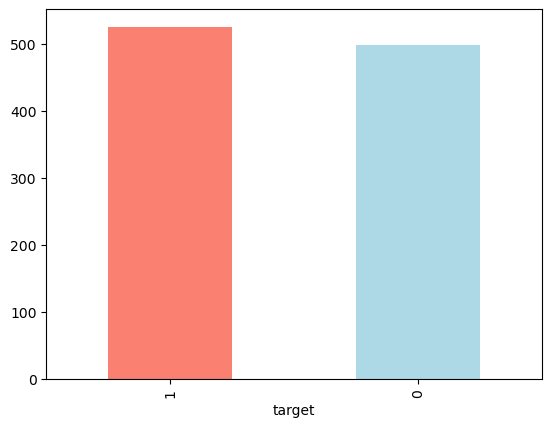

In [11]:
df["target"].value_counts().plot(kind="bar", color=["salmon", "lightblue"])
plt.show()

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


#### 2. Checking Age Distribution of Patients

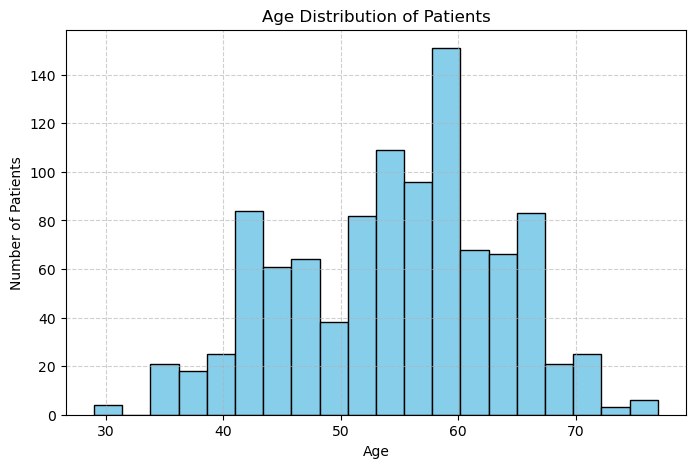

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


#### 3. Cholesterol Levels by Heart Disease Status

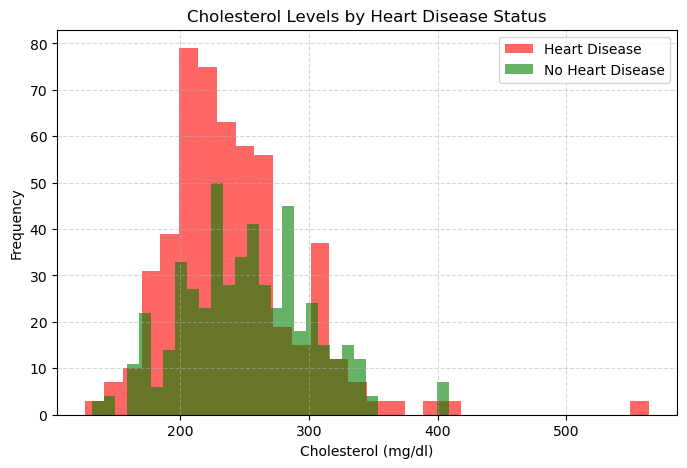

In [14]:
plt.figure(figsize=(8, 5))
df[df['target'] == 1]['chol'].hist(alpha=0.6, color='red', bins=30, label='Heart Disease')
df[df['target'] == 0]['chol'].hist(alpha=0.6, color='green', bins=30, label='No Heart Disease')
plt.title('Cholesterol Levels by Heart Disease Status')
plt.xlabel('Cholesterol (mg/dl)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


#### 4.Chest Pain Type vs Heart Diseas

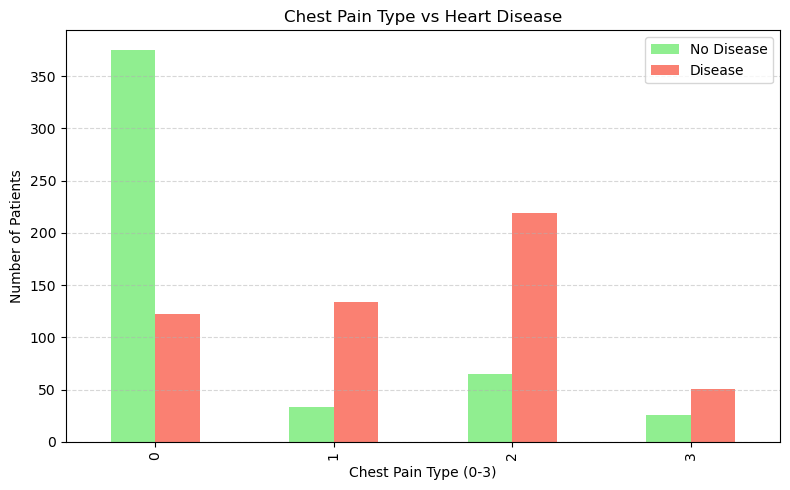

In [15]:
cp_counts = df.groupby(['cp', 'target']).size().unstack()
cp_counts.plot(kind='bar', stacked=False, color=['lightgreen', 'salmon'], figsize=(8,5))
plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain Type (0-3)')
plt.ylabel('Number of Patients')
plt.legend(['No Disease', 'Disease'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


#### 5. Maximum Heart Rate Distribution by Heart Disease Status

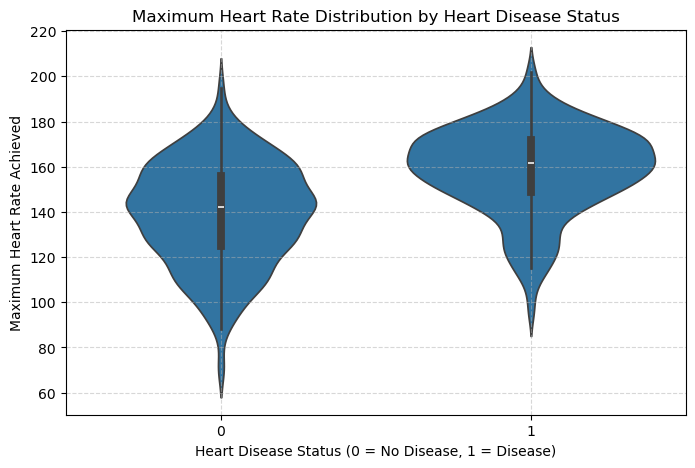

In [16]:
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.violinplot(x='target', y='thalach', data=df)
plt.title('Maximum Heart Rate Distribution by Heart Disease Status')
plt.xlabel('Heart Disease Status (0 = No Disease, 1 = Disease)')
plt.ylabel('Maximum Heart Rate Achieved')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


#### 6. Resting Blood Pressure by Heart Disease Status

C:\Users\KOMAL\AppData\Local\Temp\ipykernel_1808\1694836811.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no_disease, heart_disease], labels=['No Disease', 'Heart Disease'])


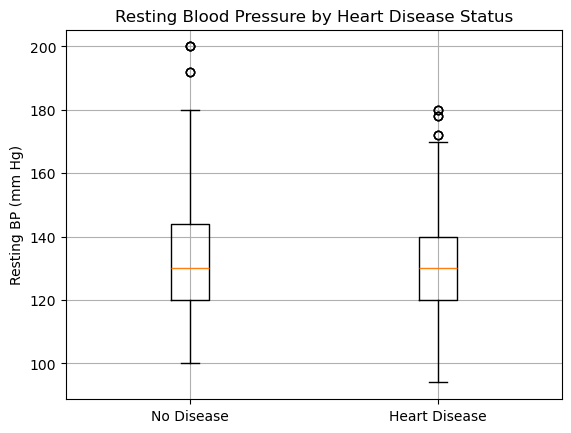

In [17]:
no_disease = df[df['target'] == 0]['trestbps']
heart_disease = df[df['target'] == 1]['trestbps']

# Plot
plt.boxplot([no_disease, heart_disease], labels=['No Disease', 'Heart Disease'])
plt.title('Resting Blood Pressure by Heart Disease Status')
plt.ylabel('Resting BP (mm Hg)')
plt.grid(True)
plt.show()


#### 7. Heart Disease Frequency according to Gender

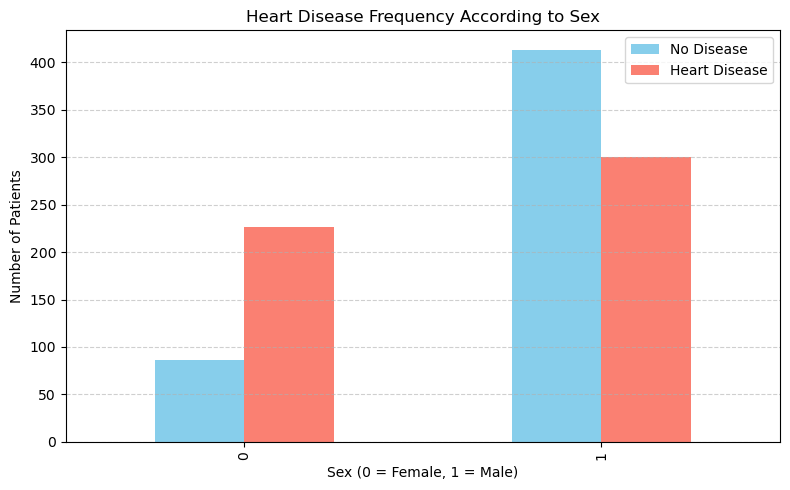

In [18]:

heart_disease_sex = df.groupby(['sex', 'target']).size().unstack()

# Plotting
heart_disease_sex.plot(kind='bar', figsize=(8,5), color=['skyblue', 'salmon'])

plt.title('Heart Disease Frequency According to Sex')
plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.ylabel('Number of Patients')
plt.legend(['No Disease', 'Heart Disease'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


#### Feature Selection
##### It is statistical method used to select import features based on their statistical meaning w.r.t. dependent features.
##### here all the columns are numeric and our target is categorical , so we will use ANOVA TEST
#### ANOVA Test🧠
##### It is used to find the "f-score" that is used to check if there is any relationship between the categorical and numerical column.Columns with highest f-score are considered as best(or having best relationship with the target.

In [19]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [20]:
numeric=df[['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal']]
categoric=df[["target"]]

In [21]:
from sklearn.feature_selection import f_classif, SelectKBest
select=SelectKBest(f_classif,k=6)
column=select.fit_transform(numeric,categoric)
selected=select.get_support(indices=True)
print(selected)
print(numeric.columns)
print(select.scores_)

[ 2  7  8  9 10 11]
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')
[ 56.78513485  86.6897071  238.55845714  20.08735284  10.32615227
   1.73635185  18.838205   222.79953804 242.88388949 243.45077988
 138.67939282 174.87707812 131.80299644]


C:\Users\KOMAL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


##### Here column -->  cp,thalach,oldpeak,slope,ca have more relationship with target

#### Using correlation matrix

In [22]:
# Make a correlation matrix
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.103240,-0.071966,0.271121,0.219823,0.121243,-0.132696,-0.390227,0.088163,0.208137,-0.169105,0.271551,0.072297,-0.229324
sex,-0.103240,1.000000,-0.041119,-0.078974,-0.198258,0.027200,-0.055117,-0.049365,0.139157,0.084687,-0.026666,0.111729,0.198424,-0.279501
cp,-0.071966,-0.041119,1.000000,0.038177,-0.081641,0.079294,0.043581,0.306839,-0.401513,-0.174733,0.131633,-0.176206,-0.163341,0.434854
trestbps,0.271121,-0.078974,0.038177,1.000000,0.127977,0.181767,-0.123794,-0.039264,0.061197,0.187434,-0.120445,0.104554,0.059276,-0.138772
chol,0.219823,-0.198258,-0.081641,0.127977,1.000000,0.026917,-0.147410,-0.021772,0.067382,0.064880,-0.014248,0.074259,0.100244,-0.099966
fbs,0.121243,0.027200,0.079294,0.181767,0.026917,1.000000,-0.104051,-0.008866,0.049261,0.010859,-0.061902,0.137156,-0.042177,-0.041164
restecg,-0.132696,-0.055117,0.043581,-0.123794,-0.147410,-0.104051,1.000000,0.048411,-0.065606,-0.050114,0.086086,-0.078072,-0.020504,0.134468
thalach,-0.390227,-0.049365,0.306839,-0.039264,-0.021772,-0.008866,0.048411,1.000000,-0.380281,-0.349796,0.395308,-0.207888,-0.098068,0.422895
exang,0.088163,0.139157,-0.401513,0.061197,0.067382,0.049261,-0.065606,-0.380281,1.000000,0.310844,-0.267335,0.107849,0.197201,-0.438029
oldpeak,0.208137,0.084687,-0.174733,0.187434,0.064880,0.010859,-0.050114,-0.349796,0.310844,1.000000,-0.575189,0.221816,0.202672,-0.438441


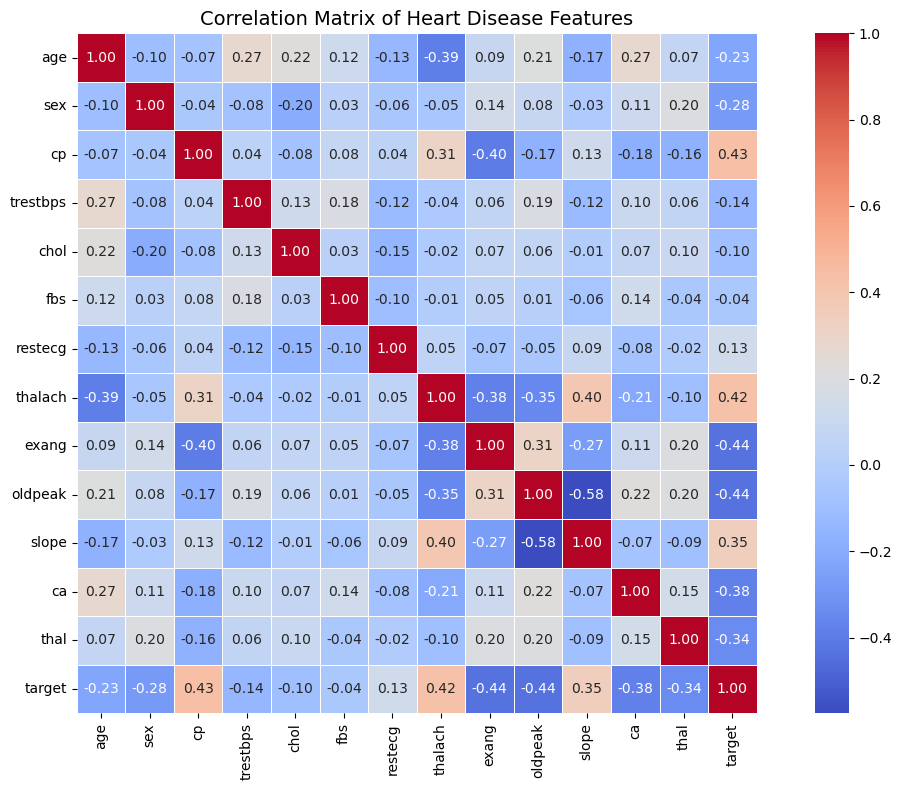

In [23]:
import seaborn as sns

corr_matrix = df.corr()

plt.figure(figsize=(12, 8))

# Create the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, square=True)

# Add titles and layout
plt.title('Correlation Matrix of Heart Disease Features', fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


#### SPLITTING INTO INDEPENDENT AND DEPENDENT VARIABLE


In [24]:
x=df.drop('target',axis=1)
y=df['target']

#### Applying Scaling

In [25]:
# from sklearn.preprocessing import StandardScaler
# s=StandardScaler()
# x=s.fit_transform(x)
# x

#### SPLITTING INTO TRAIN AND TEST SPLIT

In [26]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=12)
x_train.shape,x_test.shape

((820, 13), (205, 13))

#### STEP 4: Model Selection and Testing

In [27]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
from sklearn.svm import SVC
model=SVC(kernel="rbf",C=0.3)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [28]:
print("✅ Accuracy score for Support Vector Classifier model:", accuracy_score(y_test, y_pred))
print("🔍 Precision score (weighted):", precision_score(y_test, y_pred))
print("🔍 Recall score (weighted):", recall_score(y_test, y_pred))
print("📊 F1 score (weighted):", f1_score(y_test, y_pred))
print("📉 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

✅ Accuracy score for Support Vector Classifier model: 0.6878048780487804
🔍 Precision score (weighted): 0.671875
🔍 Recall score (weighted): 0.7962962962962963
📊 F1 score (weighted): 0.7288135593220338
📉 Confusion Matrix:
 [[55 42]
 [22 86]]


#### STEP 5: HYPERPARAMTER TUNNING
##### Hyperparameter tuning is the process of optimizing the configuration settings (called hyperparameters) of a machine learning model to get the best performance (like highest accuracy or lowest error).

In [29]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
from scipy.stats import uniform
import numpy as np

# Define the model
svc = SVC(kernel='rbf')

# Define parameter distributions to sample from
param_dist = {
    'C': uniform(loc=0.1, scale=10),        # Regularization (range: 0.1 to 10)
    'gamma': ['scale', 'auto'] + list(np.linspace(0.001, 1, 10))  # Kernel coefficient
}

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=svc,
    param_distributions=param_dist,
    n_iter=10,  # Number of parameter settings to sample
    scoring='accuracy',
    cv=5,  # 5-fold cross-validation
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit the random search model
random_search.fit(x_train, y_train)

# Best model
best_model = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)

# Predict and evaluate
y_pred = best_model.predict(x_test)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'C': 3.845401188473625, 'gamma': 0.889}


In [30]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV

# Model
model = SVC(kernel='rbf')

# Hyperparameter space
param_grid = {
    'C': [0.1, 0.3, 1, 10],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1]
}

# Random search setup
random_search = RandomizedSearchCV(model, param_grid, cv=5, n_iter=10, scoring='accuracy', random_state=42)

# Fit
random_search.fit(x_train, y_train)

# Predict
y_pred = random_search.best_estimator_.predict(x_test)

# Best parameters
print("Best Parameters:", random_search.best_params_)


Best Parameters: {'gamma': 0.1, 'C': 0.3}


In [31]:

# Create and train the model with best parameters
model = SVC(kernel='rbf', gamma=0.1)
model.fit(x_train, y_train)

# Predict on test data
y_pred = model.predict(x_test)


In [32]:
print("✅ Accuracy score for Support Vector Classifier model:", accuracy_score(y_test, y_pred))
print("🔍 Precision score (weighted):", precision_score(y_test, y_pred, average='weighted'))
print("🔍 Recall score (weighted):", recall_score(y_test, y_pred, average='weighted'))
print("📊 F1 score (weighted):", f1_score(y_test, y_pred, average='weighted'))
print("📉 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

✅ Accuracy score for Support Vector Classifier model: 0.9853658536585366
🔍 Precision score (weighted): 0.9857613711272248
🔍 Recall score (weighted): 0.9853658536585366
📊 F1 score (weighted): 0.9853511596867386
📉 Confusion Matrix:
 [[ 94   3]
 [  0 108]]


In [39]:
print(x_test)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
172   56    1   1       120   240    0        1      169      0      0.0   
374   46    0   2       142   177    0        0      160      1      1.4   
951   62    0   2       130   263    0        1       97      0      1.2   
3     61    1   0       148   203    0        1      161      0      0.0   
557   48    1   0       122   222    0        0      186      0      0.0   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
299   52    1   1       120   325    0        1      172      0      0.2   
10    71    0   0       112   149    0        1      125      0      1.6   
775   51    1   2       100   222    0        1      143      1      1.2   
957   50    1   2       140   233    0        1      163      0      0.6   
970   38    1   2       138   175    0        1      173      0      0.0   

     slope  ca  thal  
172      0   0     2  
374      0   0     2  
951      1   1    

In [38]:
print(y_pred)

[1 1 0 0 1 0 1 0 0 0 1 0 1 0 0 0 1 0 1 1 0 1 0 0 1 1 1 0 1 0 1 0 0 1 1 0 1
 1 0 1 1 0 1 1 0 1 1 1 1 0 0 1 1 0 1 1 1 1 0 0 0 1 1 1 1 0 0 1 0 1 0 0 1 0
 0 0 1 0 1 0 0 1 1 1 1 0 0 0 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 0 0 0 0 0 1 0 0
 1 0 1 1 1 0 0 0 1 1 1 1 0 0 0 0 0 0 0 1 0 1 1 1 1 1 1 1 0 1 1 1 0 1 1 0 1
 0 0 0 0 1 1 1 0 1 1 0 1 1 0 1 1 0 1 0 0 0 1 1 0 1 0 1 0 1 0 1 0 1 1 0 1 0
 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 1 1 1 0 1]


#### Step 6 : MAKING PREDICTION

In [40]:
def predict_from_user_input():
    # Take input from user
    age = float(input("Enter age: "))
    sex = int(input("Enter sex (1=male, 0=female): "))
    cp = int(input("Enter chest pain type (0-3): "))
    trestbps = float(input("Enter resting blood pressure: "))
    chol = float(input("Enter serum cholesterol (mg/dl): "))
    fbs = int(input("Fasting blood sugar > 120 mg/dl (1 = true; 0 = false): "))
    restecg = int(input("Enter resting electrocardiographic results (0-2): "))
    thalach = float(input("Enter maximum heart rate achieved: "))
    exang = int(input("Exercise induced angina (1 = yes; 0 = no): "))
    oldpeak = float(input("ST depression induced by exercise: "))
    slope = int(input("Slope of the peak exercise ST segment (0-2): "))
    ca = int(input("Number of major vessels colored by fluoroscopy (0-3): "))
    thal = int(input("Thal (1 = normal; 2 = fixed defect; 3 = reversable defect): "))

    # Create DataFrame
    input_data = {
        'age': [age],
        'sex': [sex],
        'cp': [cp],
        'trestbps': [trestbps],
        'chol': [chol],
        'fbs': [fbs],
        'restecg': [restecg],
        'thalach': [thalach],
        'exang': [exang],
        'oldpeak': [oldpeak],
        'slope': [slope],
        'ca': [ca],
        'thal': [thal]
    }
    df1 = pd.DataFrame(input_data)

    # Scale the input
   # df1_scaled = s.transform(df1)

    # Predict
    prediction = model.predict(df1)

    # Output the result
    print(prediction)
    if prediction[0] == 1:
        print("⚠️ Prediction: The patient is likely to have heart disease.")
    else:
        print("✅ Prediction: The patient is unlikely to have heart disease.")

# Run the function
predict_from_user_input()


Enter age:  62
Enter sex (1=male, 0=female):  0
Enter chest pain type (0-3):  2
Enter resting blood pressure:  130
Enter serum cholesterol (mg/dl):  263
Fasting blood sugar > 120 mg/dl (1 = true; 0 = false):  0
Enter resting electrocardiographic results (0-2):  1
Enter maximum heart rate achieved:  97
Exercise induced angina (1 = yes; 0 = no):  0
ST depression induced by exercise:  1.2
Slope of the peak exercise ST segment (0-2):  1
Number of major vessels colored by fluoroscopy (0-3):  1
Thal (1 = normal; 2 = fixed defect; 3 = reversable defect):  2


[0]
✅ Prediction: The patient is unlikely to have heart disease.


In [35]:
 prediction 

NameError: name 'prediction' is not defined

In [34]:
import pickle

with open('model1.pkl', 'wb') as f_model:
    pickle.dump(model, f_model)

print("✅ Model saved as 'model.pkl'")

✅ Model saved as 'model.pkl'
